In [ ]:
!pip install opencv-python opencv-python-headless

In [ ]:
# Download YOLOv3 weights
!wget https://pjreddie.com/media/files/yolov3.weights

# Download YOLOv3 configuration file
!wget https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg

# Download COCO class names
!wget https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names

--2025-03-20 09:21:43--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 162.0.215.52
Connecting to pjreddie.com (pjreddie.com)|162.0.215.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights’

yolov3.weights      100%[===================>] 236.52M  12.4MB/s    in 73s     

2025-03-20 09:22:58 (3.24 MB/s) - ‘yolov3.weights’ saved [248007048/248007048]

--2025-03-20 09:22:58--  https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8342 (8.1K) [text/plain]
Saving to: ‘yolov3.cfg’

yolov3.cfg          100%[===================>]   8.15K  --.-KB/s    in 0.001s  

2

In [ ]:
from google.colab import files

# Upload your image
uploaded = files.upload()

# Get the file name of the uploaded image
img_path = list(uploaded.keys())[0]
print(f"Uploaded image: {img_path}")

Saving download.jpeg to download.jpeg
Uploaded image: download.jpeg


In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

In [ ]:
def load_yolo():
    # Load YOLOv3 model
    net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")

    # Load COCO class names
    with open("coco.names", "r") as f:
        classes = [line.strip() for line in f.readlines()]

    # Get output layer names
    layers_names = net.getLayerNames()
    # Fix: Get the correct output layer indices
    output_layers = [layers_names[i - 1] for i in net.getUnconnectedOutLayers().flatten()]

    return net, classes, output_layers

In [ ]:
def load_image(img_path):
    # Load the image
    img = cv2.imread(img_path)

    # Get image dimensions
    height, width, channels = img.shape

    return img, height, width, channels

In [ ]:
def detect_objects(img, net, output_layers):
    # Create a blob from the image
    blob = cv2.dnn.blobFromImage(img, scalefactor=1/255.0, size=(416, 416), swapRB=True, crop=False)

    # Set the input for the network
    net.setInput(blob)

    # Perform forward pass and get outputs
    outputs = net.forward(output_layers)

    return outputs

In [ ]:
def get_box_dimensions(outputs, height, width):
    boxes = []
    confs = []
    class_ids = []

    for output in outputs:
        for detect in output:
            # Get class scores and class ID
            scores = detect[5:]
            class_id = np.argmax(scores)
            conf = scores[class_id]

            # Filter out weak detections (confidence > 0.5)
            if conf > 0.5:
                # Get bounding box coordinates
                center_x = int(detect[0] * width)
                center_y = int(detect[1] * height)
                w = int(detect[2] * width)
                h = int(detect[3] * height)

                # Calculate top-left corner coordinates
                x = int(center_x - w / 2)
                y = int(center_y - h / 2)

                # Append to lists
                boxes.append([x, y, w, h])
                confs.append(float(conf))
                class_ids.append(class_id)

    return boxes, confs, class_ids

In [ ]:
def draw_labels(boxes, confs, class_ids, classes, img):
    # Apply Non-Max Suppression to remove overlapping boxes
    indexes = cv2.dnn.NMSBoxes(boxes, confs, 0.5, 0.4)

    # Define font and colors
    font = cv2.FONT_HERSHEY_PLAIN
    colors = np.random.uniform(0, 255, size=(len(classes), 3))

    # Draw bounding boxes and labels
    for i in range(len(boxes)):
        if i in indexes:
            x, y, w, h = boxes[i]
            label = str(classes[class_ids[i]])
            color = colors[class_ids[i]]

            # Draw rectangle and label
            cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
            cv2.putText(img, label, (x, y - 5), font, 1, color, 1)

    return img

In [ ]:
def main():
    # Load YOLOv3 model
    net, classes, output_layers = load_yolo()

    # Load the uploaded image
    img_path = list(uploaded.keys())[0]  # Use the uploaded image
    img, height, width, channels = load_image(img_path)

    # Detect objects
    outputs = detect_objects(img, net, output_layers)

    # Get bounding boxes
    boxes, confs, class_ids = get_box_dimensions(outputs, height, width)

    # Draw bounding boxes and labels
    img_with_boxes = draw_labels(boxes, confs, class_ids, classes, img)

    # Display the final image
    cv2_imshow(img_with_boxes)

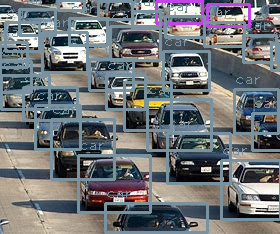

In [ ]:
if __name__ == "__main__":
    main()

In [ ]:
from google.colab import files

# Upload your image
uploaded = files.upload()

# Get the file name of the uploaded image
img_path = list(uploaded.keys())[0]
print(f"Uploaded image: {img_path}")

Saving download.jpeg to download (1).jpeg
Uploaded image: download (1).jpeg


In [ ]:
def load_yolo():
    # Load YOLOv3 model
    net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")

    # Load COCO class names
    with open("coco.names", "r") as f:
        classes = [line.strip() for line in f.readlines()]

    # Get output layer names
    layers_names = net.getLayerNames()
    # Fix: Get the correct output layer indices
    output_layers = [layers_names[i - 1] for i in net.getUnconnectedOutLayers().flatten()]

    return net, classes, output_layers

In [ ]:
def load_image(img_path):
    # Load the image
    img = cv2.imread(img_path)

    # Get image dimensions
    height, width, channels = img.shape

    return img, height, width, channels

In [ ]:
def detect_objects(img, net, output_layers):
    # Create a blob from the image
    blob = cv2.dnn.blobFromImage(img, scalefactor=1/255.0, size=(416, 416), swapRB=True, crop=False)

    # Set the input for the network
    net.setInput(blob)

    # Perform forward pass and get outputs
    outputs = net.forward(output_layers)

    return outputs

In [ ]:
def get_box_dimensions(outputs, height, width):
    boxes = []
    confs = []
    class_ids = []

    for output in outputs:
        for detect in output:
            # Get class scores and class ID
            scores = detect[5:]
            class_id = np.argmax(scores)
            conf = scores[class_id]

            # Filter out weak detections (confidence > 0.5)
            if conf > 0.5:
                # Get bounding box coordinates
                center_x = int(detect[0] * width)
                center_y = int(detect[1] * height)
                w = int(detect[2] * width)
                h = int(detect[3] * height)

                # Calculate top-left corner coordinates
                x = int(center_x - w / 2)
                y = int(center_y - h / 2)

                # Append to lists
                boxes.append([x, y, w, h])
                confs.append(float(conf))
                class_ids.append(class_id)

    return boxes, confs, class_ids

In [ ]:
def draw_labels_without_nms(boxes, confs, class_ids, classes, img):
    font = cv2.FONT_HERSHEY_PLAIN
    colors = np.random.uniform(0, 255, size=(len(classes), 3))

    # Draw all bounding boxes and labels
    for i in range(len(boxes)):
        x, y, w, h = boxes[i]
        label = str(classes[class_ids[i]])
        color = colors[class_ids[i]]

        # Draw rectangle and label
        cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
        cv2.putText(img, label, (x, y - 5), font, 1, color, 1)

    return img

In [ ]:
def draw_labels_with_nms(boxes, confs, class_ids, classes, img):
    # Apply Non-Max Suppression
    indexes = cv2.dnn.NMSBoxes(boxes, confs, 0.5, 0.4)

    font = cv2.FONT_HERSHEY_PLAIN
    colors = np.random.uniform(0, 255, size=(len(classes), 3))

    # Draw bounding boxes and labels after NMS
    for i in range(len(boxes)):
        if i in indexes:
            x, y, w, h = boxes[i]
            label = str(classes[class_ids[i]])
            color = colors[class_ids[i]]

            # Draw rectangle and label
            cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
            cv2.putText(img, label, (x, y - 5), font, 1, color, 1)

    return img

Object Detection Without NMS:


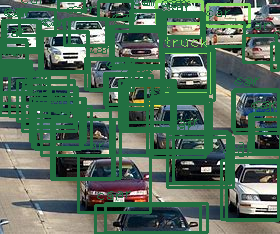

Object Detection With NMS:


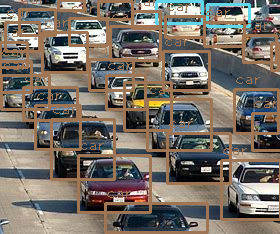

In [ ]:
def main():
    # Load YOLOv3 model
    net, classes, output_layers = load_yolo()

    # Load the uploaded image
    img_path = list(uploaded.keys())[0]  # Use the uploaded image
    img, height, width, channels = load_image(img_path)

    # Detect objects
    outputs = detect_objects(img, net, output_layers)

    # Get bounding boxes
    boxes, confs, class_ids = get_box_dimensions(outputs, height, width)

    # Create a copy of the image for comparison
    img_without_nms = img.copy()
    img_with_nms = img.copy()

    # Draw bounding boxes without NMS
    img_without_nms = draw_labels_without_nms(boxes, confs, class_ids, classes, img_without_nms)

    # Draw bounding boxes with NMS
    img_with_nms = draw_labels_with_nms(boxes, confs, class_ids, classes, img_with_nms)

    # Display results
    print("Object Detection Without NMS:")
    cv2_imshow(img_without_nms)

    print("Object Detection With NMS:")
    cv2_imshow(img_with_nms)

# Run the main function
if __name__ == "__main__":
    main()